In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(r"E:\Data Science\machine learning\Project\Categorical\bank+marketing\bank-additional\bank-additional\bank-additional-full.csv",sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Data Understanding 

In [3]:
df.shape

(41188, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [8]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [9]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [11]:
df["y"] = df["y"].map({"yes": 1, "no": 0})

In [12]:
df["y"].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

# Customer Profile Analysis

#### This section aims to analyze customers’ demographic characteristics, including age, job, marital status, and education, in order to examine how these features influence the likelihood of subscribing to a bank term deposit (y).

In [6]:
Customer_Profile = ['age', 'job', 'marital', 'education']

### Age

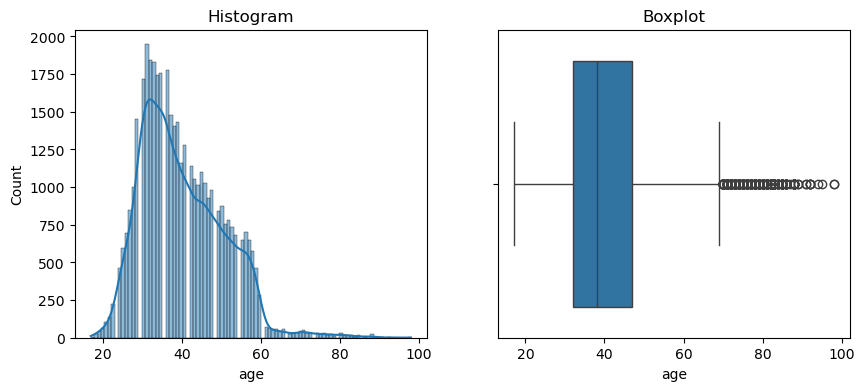

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(df['age'], kde=True, ax=axes[0])
axes[0].set_title("Histogram")

sns.boxplot(x=df['age'], ax=axes[1])
axes[1].set_title("Boxplot")

plt.show()

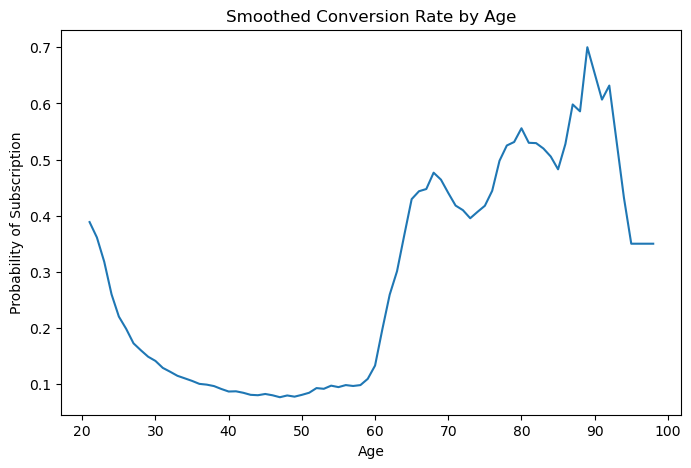

In [58]:
age_rate = df.groupby('age')['y'].apply(lambda x: (x == 1).mean()).reset_index()

age_rate['smoothed'] = age_rate['y'].rolling(window=5).mean()

plt.figure(figsize=(8,5))
plt.plot(age_rate['age'], age_rate['smoothed'])
plt.title('Smoothed Conversion Rate by Age')
plt.xlabel('Age')
plt.ylabel('Probability of Subscription')
plt.show()

##### The raw age-level conversion rate is noisy due to limited observations per age.Therefore, age was grouped into bins to obtain a smoother and more interpretable trend.

In [22]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 100],
    labels=['0-30', '30-45', '45-60', '60+'],
    right=True
)

In [68]:
age_summary = (
    df.groupby('age_group')
      .agg(
          total_customers=('y', 'size'),
          subscribers=('y', 'sum'),
          success_rate=('y', 'mean')
      )
)

age_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
age_group,,,
60+,910,414,0.454945
0-30,7383,1124,0.152242
45-60,10921,1044,0.095596
30-45,21974,2058,0.093656


##### The analysis shows a clear non-linear relationship between age and subscription probability.
##### Customers aged 60+ have a much higher conversion rate (45.5%) compared to all other groups, despite being a small portion of the dataset. In contrast, the 30–60 age group shows the lowest and most stable rates (~9–10%), while the 0–30 group performs slightly better than middle-aged customers.
##### Overall, age is a strong segmentation factor, but its effect is non-linear, with retirees being the most responsive to the campaign.

### Job

In [25]:
df["job"].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [67]:
job_summary = (
    df.groupby('job')
      .agg(
          total_customers=('y', 'size'),
          subscribers=('y', 'sum'),
          success_rate=('y', 'mean')
      )
)

job_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
job,,,
student,875,275,0.314286
retired,1720,434,0.252326
unemployed,1014,144,0.142012
admin.,10422,1352,0.129726
management,2924,328,0.112175
unknown,330,37,0.112121
technician,6743,730,0.108260
self-employed,1421,149,0.104856
housemaid,1060,106,0.100000


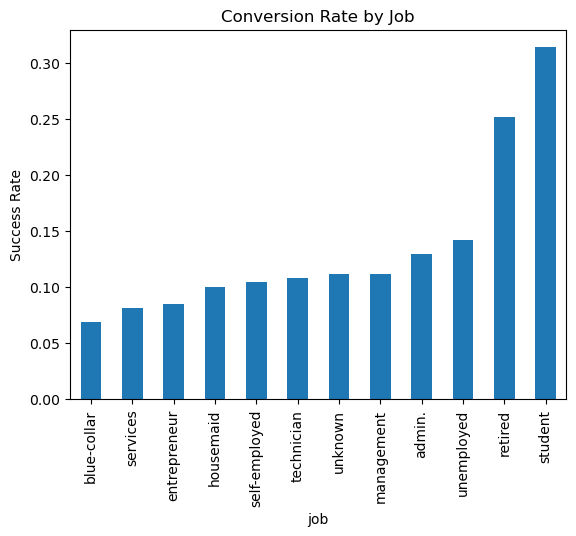

In [27]:
df.groupby('job')['y'].mean().sort_values().plot(kind='bar')
plt.title("Conversion Rate by Job")
plt.ylabel("Success Rate")
plt.show()

##### Job categories show clear differences in subscription behavior. Students (31.4%) and retired customers (25.2%) have the highest conversion rates, while blue-collar workers have the lowest (6.9%). Other groups remain in a low and stable range (8–11%).
##### Overall, job is a strong but highly segmented predictor of subscription probability, with students and retirees being the most responsive groups.

### Education

In [31]:
df["education"].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [70]:
education_summary = (
    df.groupby('education')
      .agg(
          total_customers=('y', 'size'),
          subscribers=('y', 'sum'),
          success_rate=('y', 'mean')
      )
)

education_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
education,,,
illiterate,18,4,0.222222
unknown,1731,251,0.145003
university.degree,12168,1670,0.137245
professional.course,5243,595,0.113485
high.school,9515,1031,0.108355
basic.4y,4176,428,0.102490
basic.6y,2292,188,0.082024
basic.9y,6045,473,0.078246


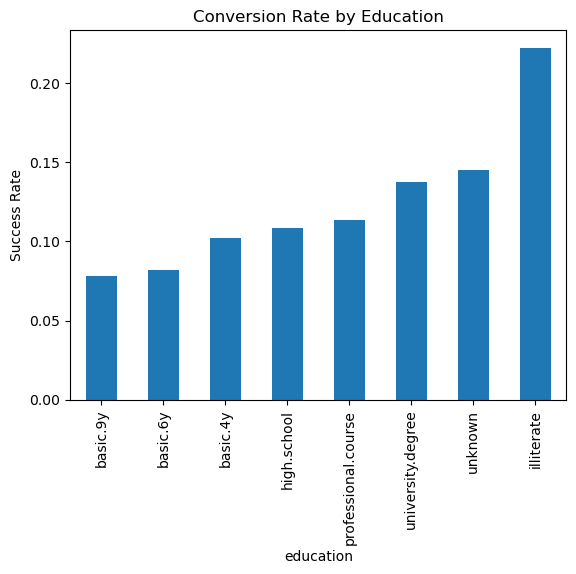

In [33]:
df.groupby('education')['y'].mean().sort_values().plot(kind='bar')
plt.title("Conversion Rate by Education")
plt.ylabel("Success Rate")
plt.show()

##### Education shows a weak-to-moderate relationship with subscription behavior. Higher conversion rates are observed in university graduates (13.7%) and the unknown group (14.5%), while basic education levels consistently show lower engagement (7–10%).
##### The illiterate group appears to have the highest rate (22%), but this result is not reliable due to the very small sample size.
##### Overall, education has limited standalone predictive power and mainly reflects broader socioeconomic differences rather than a strong direct effect.

In [65]:
pd.crosstab(df['education'], df['job'], normalize='index')

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
education,,,,,,,,,,,,
basic.4y,0.018439,0.555077,0.032807,0.113506,0.023946,0.142960,0.022270,0.031609,0.006226,0.013889,0.026820,0.012452
basic.6y,0.065881,0.622164,0.030977,0.033595,0.037086,0.032723,0.010908,0.098604,0.005672,0.037958,0.014834,0.009599
basic.9y,0.082548,0.599338,0.034739,0.015550,0.027461,0.023987,0.036394,0.064185,0.016377,0.063524,0.030769,0.005128
high.school,0.349869,0.092275,0.024593,0.018287,0.031319,0.029007,0.012401,0.281871,0.037520,0.091750,0.027220,0.003889
illiterate,0.055556,0.444444,0.111111,0.055556,0.000000,0.166667,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000
professional.course,0.069235,0.086401,0.025749,0.011253,0.016975,0.045966,0.032043,0.041579,0.008201,0.633225,0.027084,0.002289
university.degree,0.472798,0.007725,0.050131,0.011423,0.169543,0.023422,0.062870,0.014218,0.013971,0.148669,0.021532,0.003698
unknown,0.143847,0.262276,0.032929,0.024263,0.071057,0.056615,0.016753,0.086655,0.096476,0.122473,0.010976,0.075679


##### The analysis shows a strong dependency between job and education, indicating that these variables are closely related rather than independent. Clear socioeconomic patterns emerge: lower education levels are concentrated in blue-collar jobs, while higher education is mainly associated with administrative and management roles. Technical and vocational roles align with professional training, and students are mostly linked with high school education. Overall, job and education reflect a shared underlying socioeconomic structure. While this overlap may reduce their independent predictive power, it is very useful for customer segmentation.

### Marital Status

In [35]:
df["marital"].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [71]:
marital_summary = (
    df.groupby('marital')
      .agg(
          total_customers=('y', 'size'),
          subscribers=('y', 'sum'),
          success_rate=('y', 'mean')
      )
)

marital_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
marital,,,
unknown,80,12,0.150000
single,11568,1620,0.140041
divorced,4612,476,0.103209
married,24928,2532,0.101573


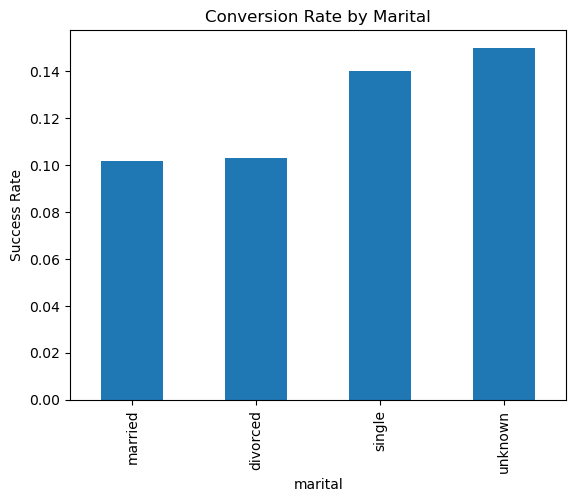

In [66]:
df.groupby('marital')['y'].mean().sort_values().plot(kind='bar')
plt.title("Conversion Rate by Marital")
plt.ylabel("Success Rate")
plt.show()

In [37]:
pd.crosstab(df['marital'], df['age_group'], normalize='index')

age_group,0-30,30-45,45-60,60+
marital,,,,
divorced,0.049653,0.503903,0.407415,0.039029
married,0.095876,0.546654,0.329509,0.027961
single,0.410702,0.517203,0.069416,0.002680
unknown,0.162500,0.500000,0.312500,0.025000


##### The analysis shows a strong dependency between marital status and age, reflecting clear life-cycle patterns in the data. Single customers are concentrated in younger ages, married individuals dominate middle ages, and divorced customers are more common in older groups.
##### Overall, marital status is not independent of age and mainly captures underlying demographic structure rather than providing separate predictive information.